Nombre y apellidos: Alfonso Íñiguez Cortés \
Correo: aic35@alu.ua.es \
Grupo: 3 

# Random Walk. Exploración de grafos

In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown 

Implementación del algoritmo Random Walk:

In [3]:
def random_walk_numpy(graph, source, target, max_steps=1000, seed=42):
    """
    Implementation of Random Walk using NumPy and standard Python lists
    
    Parameters:
    - graph: NetworkX graph (undirected, unweighted)
    - source: Source node
    - target: Target node
    - max_steps: Maximum number of steps before giving up
    - seed: Random seed for reproducibility
    
    Returns:
    - steps: Number of steps needed to find the solution
    - path: List of nodes in the path from source to target
    - success: Boolean indicating whether the target was found
    """
    np.random.seed(seed)

    nodes = list(graph.nodes())
    source_index = nodes.index(source)
    target_index = nodes.index(target)

    adjacency_matrix = nx.to_numpy_array(graph, nodelist=nodes)

    steps = 0

    success = False

    path = [source_index]   

    while steps < max_steps:
        steps  += 1
        valor_actual = path[-1]
        if valor_actual == target_index:
            success = True
            break

        neighbors = np.where(adjacency_matrix[valor_actual] == 1)[0]
        next_position = np.random.choice(neighbors)
        path.append(next_position)
    
    node_path = []
    for i in path:
        node_path.append(nodes[i])


    return steps, node_path, success

## Ejercicios

### Ejercicio 1

El algoritmo Random Walk es un algoritmo de exploración de grafos. A diferencia de BFS y DFS, este algoritmo no sigue ninguna estrategia fija: en cada paso elige aleatoriamente uno de los vecinos del nodo actual y se mueve hacia él, pudiendo incluso volver a nodos ya visitados.
Esto significa que **no garantiza el camino más corto** ni siquiera un camino sin repeticiones, pero es útil para modelar procesos aleatorios sobre grafos. Tiene un parámetro **max_steps** que limita el número máximo de pasos para evitar bucles infinitos.

### Explicación algoritmo

- #### Bloque 1 - Inicialización
---

In [ ]:
np.random.seed(seed)

nodes = list(graph.nodes())
adjacency_matrix = nx.to_numpy_array(graph, nodelist=nodes)
source_index = nodes.index(source)
target_index = nodes.index(target)

steps = 0
success = False
path = [source_index]   

- **np.random.seed(seed)** &rarr; Fijamos la semilla aleatoria para que los resultados sean reproducibles. Sin esto, cada ejecución daría un camino distinto

- **nodes** &rarr; Lista ordenada de todos los nodos del grafo. La lista es necesaria puesto que se trabaja con los índices de los nodos, no con los nombres reales de estos.

- **adjacency_matrix** &rarr; Matriz NxN donde la celda ```[i][j] = 1``` si hay una arsita entre el nodo i y el nodo j. Si no hay arista, el valor correspondiente es 0.

- **source_index** &rarr; Índice del nodo donde comienza la búsqueda

- **target_index** &rarr; Índice del nodo que queremos alcanzar 

- **steps** &rarr; Contador de iteraciones del bucle principal

- **success** &rarr; Booleano que indica si el algoritmo ha encontrado el destino antes de agotar el máximo de pasos

- **path** &rarr; Lista que guarda el camino recorrido. A diferencia de BFS y DFS, aquí guardamos **todos los nodos visitados**, no solo los del camino final, ya que el algoritmo puede pasar por el mismo nodo varias veces.

- #### Bucle principal
---

In [ ]:
while steps < max_steps:
    steps  += 1
    valor_actual = path[-1]
    if valor_actual == target_index:
        success = True
        break

    neighbors = np.where(adjacency_matrix[valor_actual] == 1)[0]
    next_position = np.random.choice(neighbors)
    path.append(next_position)

- _while_ &rarr; El bucle continúa hasta encontrar el destino o agotar **max_steps**. A diferencia de BFS y DFS, aquí no hay garantía de terminar sin ese límite ya que el algoritmo puede dar vueltas indefinidamente

- **valor_actual** &rarr;  El nodo donde estamos ahora, que es siempre el último elemento del camino recorrido

- **steps** &rarr; Sumamos uno por iteración

- _if_ &rarr; Comprobamos si hemos llegado al destino **antes** de movernos. Si es así, marcamos `success = True` y paramos

- **neighbors** &rarr; Mira la fila del nodo actual en la matriz de adyacencia y devuelve los índices donde haya un uno, es decir, donde exista una arsita, es decir, sus vecinos

- **next_position** &rarr; Elegimos aleatoriamente uno de los vecinos. Esta es la diferencia clave respecto a BFS y DFS: no hay ningún criterio de selección, es puramente aleatorio

- **path.append** &rarr; Añadimos el siguiente nodo al camino. El camino puede contener nodos repetidos, al contrario que en BFS y DFS

- #### Bloque 3 - Reconstrucción del camino
---

In [ ]:
node_path = []
for i in path:
    node_path.append(nodes[i])


return steps, node_path, success

- **node_path** &rarr; Convertimos los índices numéricos del camino de vuelta a los nombres reales de los nodos. A diferencia de BFS y DFS, no hay que reconstruir nada hacia atrás porque el camino se ha ido guardando en orden durante la exploración

- _for_ &rarr; Bucle que recorre los nodos del camino que se ha generado

- **node_path.append** &rarr; Añadimos el nodo actual a la lista. Como los nodos ya están ordenados, simplemente los vamos añadiendo al final de la lista

- **success** &rarr; Devolvemos también si el algoritmo encontró el destino o se quedó sin pasos. Es un valor extra respecto a BFS y DFS porque Random Walk puede no llegar nunca

#### Random Walk con prints

In [5]:
def random_walk_numpy(graph, source, target, max_steps=1000, seed=42):
    """
    Función que implementa el algoritmo Random Walk. Se usan prints para 
    que se muestre que pasos esta siguiendo el algoritmo.

    Args
    -------
        - graph: Grafo que se va a explorar
        - source: Nodo del que se comienza la exploración
        - target: Nodo que se quiere encontrar
        - max_steps: Pasos máximos que tiene el algoritmo
        - seed: Para que los caminos aleatorios sean reproducibles

    Returns
    --------
        - steps: Número de pasos que usa BFS para encontrar el camino
        - path: Camino entre source y target
        - succes: Indica si el algoritmo ha encontrado el destino con los
                  pasos que tenía disponibles
    
    """

    display(Markdown(f'## Analizando el grafo con Random Walk \n---'))
    np.random.seed(seed)

    nodes = list(graph.nodes())
    source_index = nodes.index(source)
    target_index = nodes.index(target)

    adjacency_matrix = nx.to_numpy_array(graph, nodelist=nodes)

    steps = 0

    success = False

    path = [source_index]   

    # Inicialización
    display(Markdown(f'### <u>Datos iniciales</u>'))
    print(f'Nodos: {nodes}')
    print(f'Nodo inicial: {nodes[source_index]}')
    print(f'Nodo a buscar: {nodes[target_index]}')
    print(f'Pasos disponibles: {max_steps}')

    display(Markdown(f'_iniciando búsqueda..._'))
    while steps < max_steps:
        steps  += 1
        valor_actual = path[-1]
        if valor_actual == target_index:
            success = True
            break

        neighbors = np.where(adjacency_matrix[valor_actual] == 1)[0]
        next_position = np.random.choice(neighbors)
        path.append(next_position)
    
    node_path = []
    for i in path:
        node_path.append(nodes[i])

    display(Markdown(f'### Resultados obtenidos\n---'))
    if success:
        print(f'El algoritmo ha podido generar un camino')
        print(f'Número de pasos: {steps}')
        print(f'Camino: {path}')
        print(f'Longitud del camino; {len(path) - 1} aristas')

    else:
        print('No se ha podido generar un camino')
    return steps, node_path, success

## Grafos sintéticos

#### **ERDOS-RENYI**

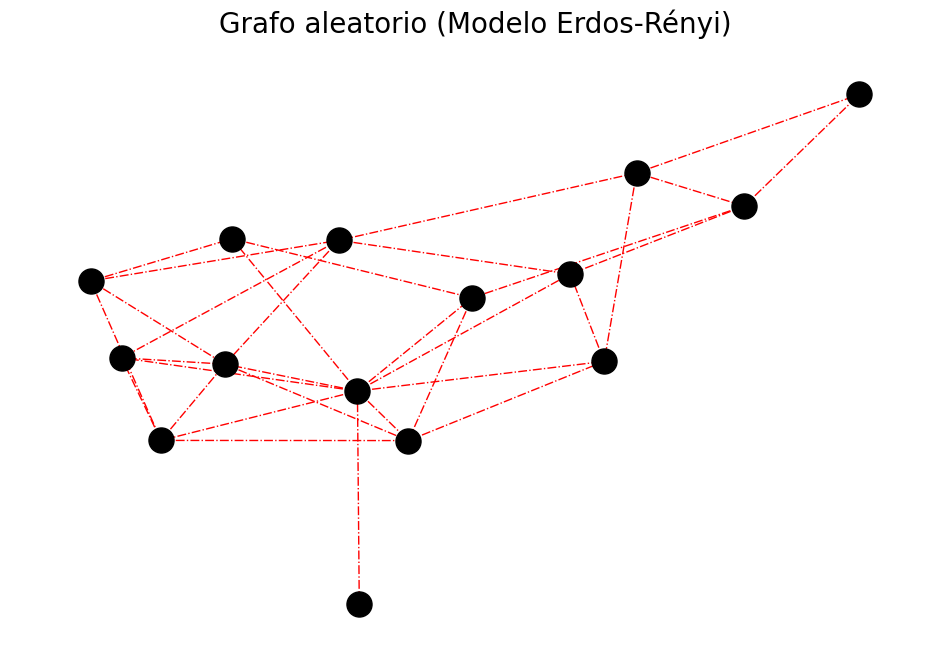

---

## Analizando el grafo con Random Walk 
---

### <u>Datos iniciales</u>

Nodos: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
Nodo inicial: 4
Nodo a buscar: 7
Pasos disponibles: 1000


_iniciando búsqueda..._

### Resultados obtenidos
---

El algoritmo ha podido generar un camino
Número de pasos: 5
Camino: [4, 10, 12, 10, 7]
Longitud del camino; 4 aristas


(5, [4, 10, 12, 10, 7], True)

In [6]:
######################################
# ERDOS-RENYI
######################################

e_r = nx.erdos_renyi_graph(15, 0.25)   # 15 nodos | Probabilidad de arista del 25%

# Mostramos el grafo por pantalla
plt.figure(figsize=(12,8))
plt.title('Grafo aleatorio (Modelo Erdos-Rényi)', fontsize = 20)

# Vamos a calcular la posiciones (nodos)
posiciones = nx.spring_layout(e_r, seed = 18)

# Dibujamos los nodos y arsitas
nx.draw_networkx_nodes(e_r, posiciones, node_color = 'black', node_size = 325)
nx.draw_networkx_edges(e_r, posiciones, edge_color = 'red', style = '-.')

plt.axis('off')
plt.show()
display(Markdown("---"))

# EJECUTAMOS EL AGORITMO
random_walk_numpy(e_r, 4, 7)

---

#### **BARABASI-ALBERT**

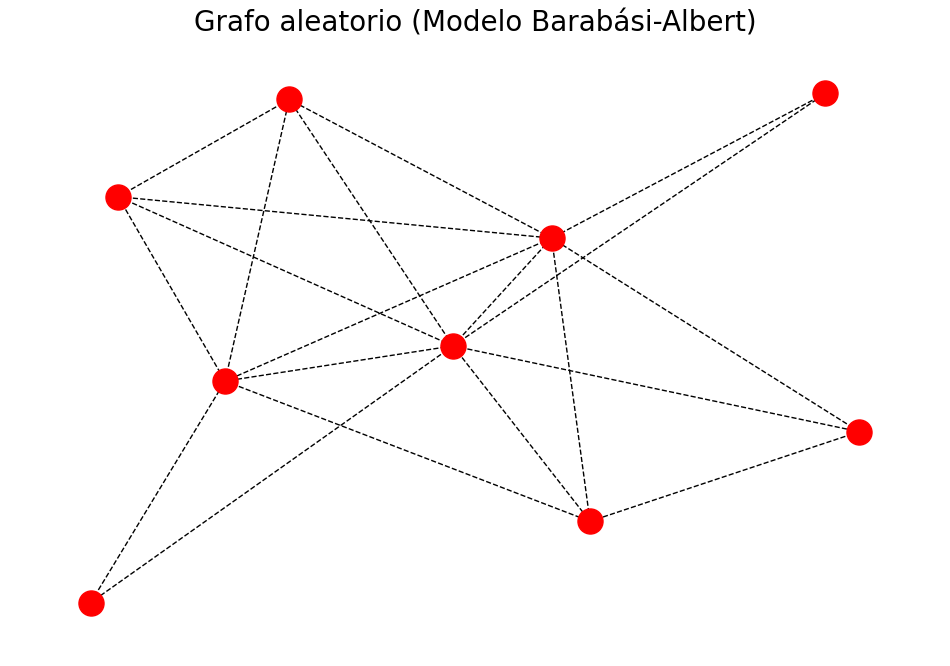

---

## Analizando el grafo con Random Walk 
---

### <u>Datos iniciales</u>

Nodos: [0, 1, 2, 3, 4, 5, 6, 7, 8]
Nodo inicial: 4
Nodo a buscar: 8
Pasos disponibles: 1000


_iniciando búsqueda..._

### Resultados obtenidos
---

El algoritmo ha podido generar un camino
Número de pasos: 7
Camino: [4, 7, 6, 7, 5, 3, 8]
Longitud del camino; 6 aristas


(7, [4, 7, 6, 7, 5, 3, 8], True)

In [7]:
######################################
# BARABASI-ALBERT
######################################

b_a = nx.barabasi_albert_graph(9, 4, seed=10)   # 10 nodos | Nº enlaces por nodo

# Mostramos el grafo por pantalla
plt.figure(figsize=(12,8))
plt.title('Grafo aleatorio (Modelo Barabási-Albert)', fontsize = 20)

# Vamos a calcular la posiciones (nodos)
posiciones = nx.spring_layout(b_a, seed = 8)

# Dibujamos los nodos y arsitas
nx.draw_networkx_nodes(b_a, posiciones, node_color = 'red', node_size = 325)
nx.draw_networkx_edges(b_a, posiciones, edge_color = 'black', style = '--')

plt.axis('off')
plt.show()
display(Markdown("---"))

# CALCULAMOS EL ALGORITMO
random_walk_numpy(b_a, 4,8)

---

#### **WATTS-STROGATZ**

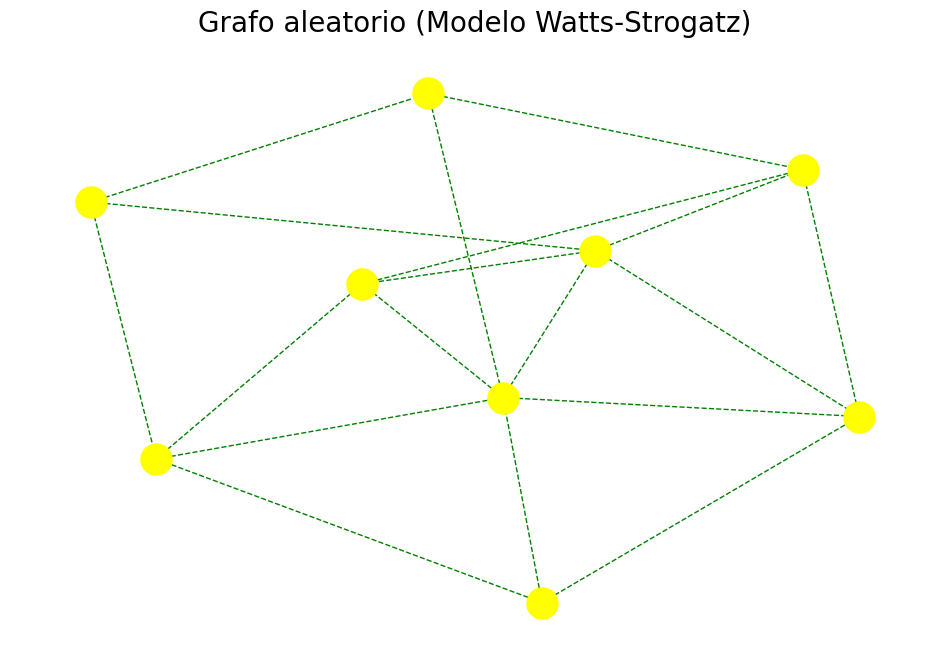

---

## Analizando el grafo con Random Walk 
---

### <u>Datos iniciales</u>

Nodos: [0, 1, 2, 3, 4, 5, 6, 7, 8]
Nodo inicial: 6
Nodo a buscar: 8
Pasos disponibles: 1000


_iniciando búsqueda..._

### Resultados obtenidos
---

El algoritmo ha podido generar un camino
Número de pasos: 6
Camino: [6, 7, 6, 1, 6, 8]
Longitud del camino; 5 aristas


(6, [6, 7, 6, 1, 6, 8], True)

In [8]:
######################################
# WATTS-STROGATZ
######################################

w_s = nx.watts_strogatz_graph(9, 4, 0.5)   # 9 nodos | Grado medio | Probabilidad reconexión

# Mostramos el grafo por pantalla
plt.figure(figsize=(12,8))
plt.title('Grafo aleatorio (Modelo Watts-Strogatz)', fontsize = 20)

# Vamos a calcular la posiciones (nodos)
posiciones = nx.spring_layout(w_s, seed = 16)

# Dibujamos los nodos y arsitas
nx.draw_networkx_nodes(w_s, posiciones, node_color = 'yellow', node_size = 500)
nx.draw_networkx_edges(w_s, posiciones, edge_color = 'green', style = '--')

plt.axis('off')
plt.show()
display(Markdown("---"))

# EJECUTAMOS EL ALGORTIMO
random_walk_numpy(w_s, 6, 8)

#### **GRAFOS EN ÁRBOL**

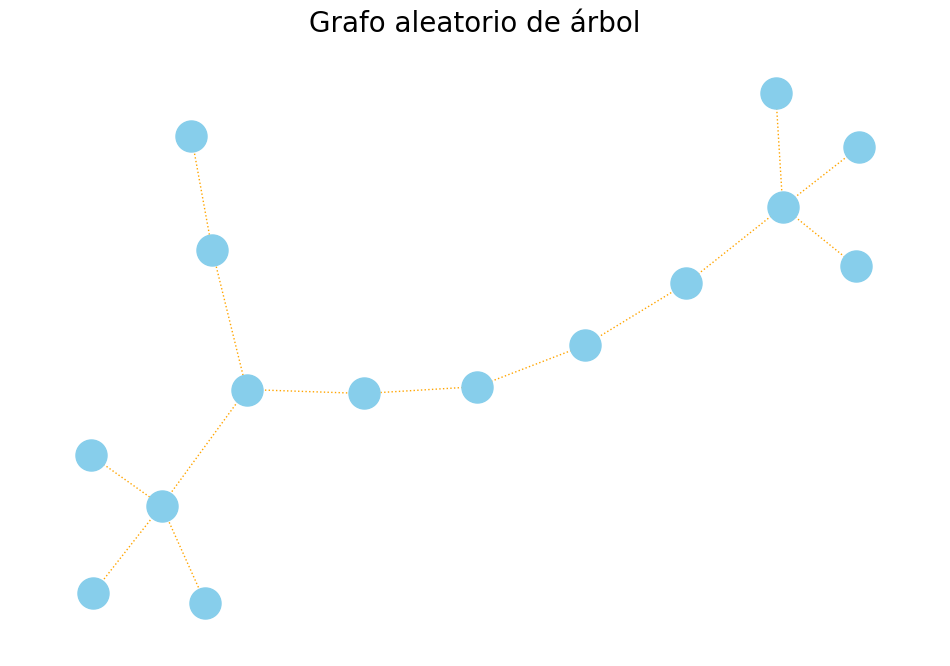

---

## Analizando el grafo con Random Walk 
---

### <u>Datos iniciales</u>

Nodos: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
Nodo inicial: 2
Nodo a buscar: 7
Pasos disponibles: 1000


_iniciando búsqueda..._

### Resultados obtenidos
---

El algoritmo ha podido generar un camino
Número de pasos: 15
Camino: [2, 12, 2, 3, 10, 3, 10, 3, 13, 3, 2, 3, 10, 3, 7]
Longitud del camino; 14 aristas


(15, [2, 12, 2, 3, 10, 3, 10, 3, 13, 3, 2, 3, 10, 3, 7], True)

In [9]:
######################################
# TREE
######################################

# Usamos la función "random_tree" para generar un grafo de árbol
t = nx.random_tree(15, seed=99)   # 15 nodos

# Mostramos el grafo por pantalla
plt.figure(figsize=(12,8))
plt.title('Grafo aleatorio de árbol', fontsize = 20)

# Vamos a calcular la posiciones (nodos)
posiciones = nx.spring_layout(t, seed = 16)

# Dibujamos los nodos y arsitas
nx.draw_networkx_nodes(t, posiciones, node_color = 'skyblue', node_size = 500)
nx.draw_networkx_edges(t, posiciones, edge_color = 'orange', style = ':')

plt.axis('off')
plt.show()
display(Markdown("---"))

# EJECUTAMOS EL ALGORITMO
random_walk_numpy(t, 2, 7)

#### **STOCHASTIC BLOCK MODEL**

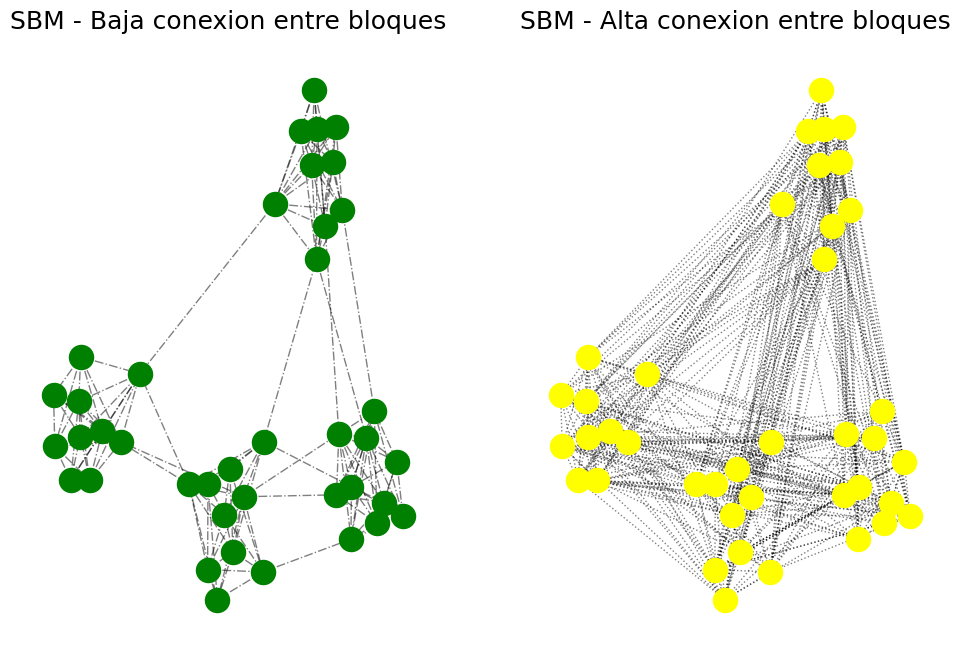

## Analizando el grafo con Random Walk 
---

### <u>Datos iniciales</u>

Nodos: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 32, 33, 34, 35, 36, 37, 38, 39, 30, 31]
Nodo inicial: 6
Nodo a buscar: 13
Pasos disponibles: 1000


_iniciando búsqueda..._

### Resultados obtenidos
---

...

Nodos: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 32, 33, 34, 35, 36, 37, 38, 39, 30, 31]
Nodo inicial: 6
Nodo a buscar: 13
Pasos disponibles: 1000


_iniciando búsqueda..._

### Resultados obtenidos
---

El algoritmo ha podido generar un camino
Número de pasos: 57
Camino: [6, 8, 27, 16, 19, 33, 38, 20, 25, 23, 37, 7, 14, 3, 36, 3, 18, 25, 11, 1, 0, 15, 20, 36, 20, 33, 30, 35, 36, 30, 8, 6, 8, 17, 12, 3, 4, 23, 26, 37, 26, 23, 37, 1, 39, 31, 28, 15, 20, 21, 35, 6, 27, 26, 9, 2, 13]
Longitud del camino; 56 aristas


(57,
 [6,
  8,
  27,
  16,
  19,
  35,
  30,
  20,
  25,
  23,
  39,
  7,
  14,
  3,
  38,
  3,
  18,
  25,
  11,
  1,
  0,
  15,
  20,
  38,
  20,
  35,
  32,
  37,
  38,
  32,
  8,
  6,
  8,
  17,
  12,
  3,
  4,
  23,
  26,
  39,
  26,
  23,
  39,
  1,
  31,
  33,
  28,
  15,
  20,
  21,
  37,
  6,
  27,
  26,
  9,
  2,
  13],
 True)

In [10]:
######################################
# STOCHASTIC_BLOCK_MODEL (SBM)
######################################
# Creamos 4 bloques de 10 nodos cada uno
sizes = [10, 10, 10, 10]

# Definimos las matrices de probabilidad:
    # Baja: Probabilidad baja conexión entre bloques distintos
    # Alta: Probabilidad alta conexión entre bloques distintos
baja = [
    [0.8, 0.02, 0.02, 0.02],
    [0.02, 0.8, 0.02, 0.02],
    [0.02, 0.02, 0.8, 0.02],
    [0.02, 0.02, 0.02, 0.8]
]
alta = [
    [0.8, 0.4, 0.4, 0.4],
    [0.4, 0.8, 0.4, 0.4],
    [0.4, 0.4, 0.8, 0.4],
    [0.4, 0.4, 0.4, 0.8]
]
# Definimos la semilla para que los resultados sean reproducibles
seed = 96

# Creamos los 2 grafos (SBM)
G1 = nx.stochastic_block_model(sizes, baja, seed=seed)  # El primero -> Probabilidad alta
G2 = nx.stochastic_block_model(sizes, alta, seed=seed)  # El segundo -> Probabilidad baja

# Calculamos las posiciones (las mismas para los dos grafos)
pos = nx.spring_layout(G1, seed=seed)
# Vamos a dividir los dos grafos en una misma figura
fig, axes = plt.subplots(1, 2, figsize=(12,8))

# Primer grafo
#--------------#
# Definimos título
axes[0].set_title('SBM - Baja conexion entre bloques', fontsize = 18)  
nx.draw_networkx_nodes(G1, pos, node_size=300, node_color='green', ax=axes[0])  # Dibujamos los nodos
nx.draw_networkx_edges(G1, pos, width=1.0, alpha=0.5, edge_color='black', style='-.', ax=axes[0]) # Dibujamos las aristas
axes[0].axis('off')

# Segundo grafo
#---------------#
# Definimos título
axes[1].set_title('SBM - Alta conexion entre bloques', fontsize = 18)
nx.draw_networkx_nodes(G2, pos, node_size=300, node_color= 'yellow', ax=axes[1])         # Dibujamos los nodos
nx.draw_networkx_edges(G2, pos, width=1.0, alpha=0.5, style=':', ax=axes[1])  # Dibujamos las arsitas
axes[1].axis('off')

# Mostramos el resultado por pantalla
plt.show()


# EJECUTAMOS EL ALGORITMO
random_walk_numpy(G1, 6, 13)
display(Markdown(f'---'))
display(Markdown(f'---'))
random_walk_numpy(G2, 6, 13)

# Ejercicio 2

Vamos a aplicar el algoritmo a los grafos sintéticos creados anteriormente mostrando un ejemplo donde los nodos destino y origen están cerca y otro donde estén lejos

---
#### **ERDOS-RÉNYI**

In [11]:
random_walk_numpy(e_r, 0, 1) # CERCA
random_walk_numpy(e_r, 0, 14) # LEJOS

## Analizando el grafo con Random Walk 
---

### <u>Datos iniciales</u>

Nodos: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
Nodo inicial: 0
Nodo a buscar: 1
Pasos disponibles: 1000


_iniciando búsqueda..._

### Resultados obtenidos
---

...

Nodos: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
Nodo inicial: 0
Nodo a buscar: 14
Pasos disponibles: 1000


_iniciando búsqueda..._

### Resultados obtenidos
---

El algoritmo ha podido generar un camino
Número de pasos: 4
Camino: [0, 2, 12, 14]
Longitud del camino; 3 aristas


(4, [0, 2, 12, 14], True)

---
#### **BARABÁSI-ALBERT**

In [12]:
random_walk_numpy(b_a, 0, 1) # CERCA
random_walk_numpy(b_a, 0, 5) # LEJOS

## Analizando el grafo con Random Walk 
---

### <u>Datos iniciales</u>

Nodos: [0, 1, 2, 3, 4, 5, 6, 7, 8]
Nodo inicial: 0
Nodo a buscar: 1
Pasos disponibles: 1000


_iniciando búsqueda..._

### Resultados obtenidos
---

...

Nodos: [0, 1, 2, 3, 4, 5, 6, 7, 8]
Nodo inicial: 0
Nodo a buscar: 5
Pasos disponibles: 1000


_iniciando búsqueda..._

### Resultados obtenidos
---

El algoritmo ha podido generar un camino
Número de pasos: 5
Camino: [0, 7, 6, 7, 5]
Longitud del camino; 4 aristas


(5, [0, 7, 6, 7, 5], True)

---
#### **GRAFOS DE MUNDOS PEQUEÑOS**

In [13]:
random_walk_numpy(w_s, 0, 1) # CERCA
random_walk_numpy(w_s, 0, 5) # LEJOS

## Analizando el grafo con Random Walk 
---

### <u>Datos iniciales</u>

Nodos: [0, 1, 2, 3, 4, 5, 6, 7, 8]
Nodo inicial: 0
Nodo a buscar: 1
Pasos disponibles: 1000


_iniciando búsqueda..._

### Resultados obtenidos
---

...

Nodos: [0, 1, 2, 3, 4, 5, 6, 7, 8]
Nodo inicial: 0
Nodo a buscar: 5
Pasos disponibles: 1000


_iniciando búsqueda..._

### Resultados obtenidos
---

El algoritmo ha podido generar un camino
Número de pasos: 9
Camino: [0, 4, 0, 4, 6, 8, 1, 8, 5]
Longitud del camino; 8 aristas


(9, [0, 4, 0, 4, 6, 8, 1, 8, 5], True)

---
#### **GRAFOS EN ÁRBOL**

In [14]:
random_walk_numpy(t, 0, 1) # CERCA
random_walk_numpy(t, 0, 14) # LEJOS

## Analizando el grafo con Random Walk 
---

### <u>Datos iniciales</u>

Nodos: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
Nodo inicial: 0
Nodo a buscar: 1
Pasos disponibles: 1000


_iniciando búsqueda..._

### Resultados obtenidos
---

...

Nodos: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
Nodo inicial: 0
Nodo a buscar: 14
Pasos disponibles: 1000


_iniciando búsqueda..._

### Resultados obtenidos
---

El algoritmo ha podido generar un camino
Número de pasos: 57
Camino: [0, 6, 11, 6, 0, 6, 11, 4, 11, 4, 1, 4, 11, 4, 1, 4, 1, 12, 1, 12, 2, 12, 2, 3, 7, 3, 13, 3, 13, 3, 7, 3, 7, 3, 7, 3, 13, 3, 13, 3, 2, 3, 13, 3, 7, 3, 7, 3, 2, 3, 2, 12, 1, 4, 11, 6, 14]
Longitud del camino; 56 aristas


(57,
 [0,
  6,
  11,
  6,
  0,
  6,
  11,
  4,
  11,
  4,
  1,
  4,
  11,
  4,
  1,
  4,
  1,
  12,
  1,
  12,
  2,
  12,
  2,
  3,
  7,
  3,
  13,
  3,
  13,
  3,
  7,
  3,
  7,
  3,
  7,
  3,
  13,
  3,
  13,
  3,
  2,
  3,
  13,
  3,
  7,
  3,
  7,
  3,
  2,
  3,
  2,
  12,
  1,
  4,
  11,
  6,
  14],
 True)

---
#### **MODELO DE BLOQUES ESTOCÁSTICOS**

In [15]:
# POCA CONEXIÓN ENTRE COMUNIDADES
random_walk_numpy(G1, 0, 2) # CERCA
random_walk_numpy(G1, 0, 35) # LEJOS

print()
print()
print()

# MUCHA CONEXIÓN ENTRE COMUNIDADES
random_walk_numpy(G2, 0, 2) # CERCA
random_walk_numpy(G2, 0, 35) # LEJOS

## Analizando el grafo con Random Walk 
---

### <u>Datos iniciales</u>

Nodos: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 32, 33, 34, 35, 36, 37, 38, 39, 30, 31]
Nodo inicial: 0
Nodo a buscar: 2
Pasos disponibles: 1000


_iniciando búsqueda..._

### Resultados obtenidos
---

...

Nodos: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 32, 33, 34, 35, 36, 37, 38, 39, 30, 31]
Nodo inicial: 0
Nodo a buscar: 35
Pasos disponibles: 1000


_iniciando búsqueda..._

### Resultados obtenidos
---

El algoritmo ha podido generar un camino
Número de pasos: 7
Camino: [0, 9, 5, 27, 16, 19, 33]
Longitud del camino; 6 aristas


(7, [0, 9, 5, 27, 16, 19, 35], True)

# Resultados obtenidos y conclusión

Hemos aplicado el algoritmo Random Walk a los cinco tipos de grafos sintéticos. A diferencia de BFS y DFS, Random Walk no garantiza encontrar el destino ni seguir un camino sin repeticiones, por lo que el número de pasos puede ser muy alto y el camino resultante contiene nodos visitados varias veces. En Erdős-Rényi, el algoritmo encuentra el destino con relativa facilidad gracias a la distribución uniforme de conexiones, aunque el camino es mucho más largo que el que encontraría BFS. En Barabási-Albert, los hubs actúan como imanes: el algoritmo tiende a pasar por ellos repetidamente, lo que puede acelerar o ralentizar la búsqueda dependiendo de si el hub está cerca del destino. En Watts-Strogatz, la propiedad de mundo pequeño ayuda a que el algoritmo no quede atrapado en zonas aisladas, pero los pasos siguen siendo considerablemente más que en BFS o DFS. En el árbol, Random Walk puede ser muy ineficiente: sin ciclos, el algoritmo puede rebotar entre ramas durante mucho tiempo antes de encontrar el camino correcto. En el SBM, G1 es el caso más problemático: con pocas conexiones entre bloques, el algoritmo puede quedarse atrapado dentro de una comunidad durante muchos pasos antes de encontrar el puente hacia el destino, mientras que en G2 la alta densidad facilita cruzar entre bloques más rápidamente

**¿Cómo se comporta el algoritmo en estos grafos?** \
&rarr; Random Walk encuentra el destino en la mayoría de casos si se le dan suficientes pasos, pero el camino resultante es generalmente mucho más largo que el de BFS o DFS ya que puede pasar por el mismo nodo múltiples veces. El número de pasos necesarios es impredecible y depende tanto de la estructura del grafo como de la aleatoriedad inherente al algoritmo. El parámetro max_steps es clave: si es demasiado bajo, el algoritmo puede no llegar al destino en grafos dispersos como el SBM G1

**¿Cómo se compara la ruta DFS con la ruta más corta que encuentra BFS?** \
&rarr; Random Walk no es la mejor opción para encontrar caminos cortos o garantizar la llegada al destino, pero tiene usos específicos donde BFS y DFS no aplican. Es útil para modelar procesos estocásticos reales sobre grafos, como la difusión de información en redes sociales o el movimiento de partículas. También se usa en grafos enormes donde BFS y DFS serían inviables por memoria, ya que Random Walk no necesita mantener una cola ni una pila. Otro uso importante es el muestreo de grafos: cuando el grafo es tan grande que no se puede explorar entero, un paseo aleatorio permite obtener una muestra representativa de sus nodos y estructuras. En cambio, para cualquier tarea donde se necesite garantía de llegar al destino o encontrar el camino más corto, BFS sigue siendo la mejor opción